# Gym Duckietown 🦆

Gym-Duckietown is a simulator for the Duckietown Universe, written in pure Python/OpenGL (Pyglet). It places your agent, a Duckiebot, inside of an instance of a Duckietown: a loop of roads with turns, intersections, obstacles, Duckie pedestrians, and other Duckiebots. It can be a pretty hectic place!

Have a look at the GitHub repo for more details: https://github.com/duckietown/gym-duckietown

There are several maps and tracks available which can be accessed through registered gym environments, each corresponding to a different map file:

- Duckietown-straight_road-v0
- Duckietown-4way-v0
- Duckietown-udem1-v0
- Duckietown-small_loop-v0
- Duckietown-small_loop_cw-v0
- Duckietown-zigzag_dists-v0
- Duckietown-loop_empty-v0
- Duckietown-loop_obstacles-v0 (static obstacles in the road)
- Duckietown-loop_pedestrians-v0 (moving obstacles in the road)

We will work with the following for our challenges:

- Getting Started: Duckietown-small_loop-v0
- Basic: Duckietown-small_loop-v0
- Medium: Duckietown-loop_empty-v0
- Advanced: Duckietown-loop_obstacles-v0 (static obstacles in the road)

- Bonus: Duckietown-zigzag_dists-v0, Duckietown-loop_pedestrians-v0 (moving obstacles in the road)

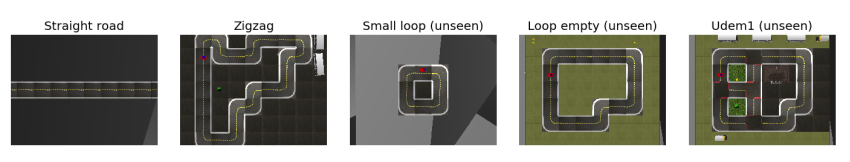


Below is the standard control loop with the small loop environment loaded:

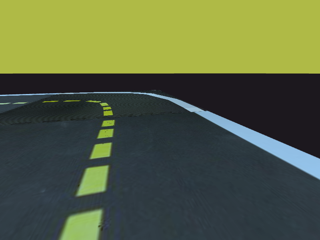

INFO:gym-duckietown:Starting at [0.73022359 0.         0.2058572 ] 2.4079195227572203


In [15]:
import gym
import gym_duckietown
from IPython.display import display, clear_output
from PIL import Image

# Create the environment
env = gym.make('Duckietown-small_loop-v0')
env.reset()

# Helper function to display an image in Jupyter notebook
def show_array(arr):
    img = Image.fromarray(arr, 'RGB')
    # Make the image smaller to increase the FPS of the notebook
    img = img.resize((320, 240))
    display(img)

# Run the simulation until we're done
done = False
while not done:
    # Get a random action
    action = env.action_space.sample()
    # Perform the action, step the environment forward by one frame and get the observation, reward, done, and info
    observation, reward, done, info = env.step(action)
    # Render the frame to an array of RGB values
    frame = env.render(mode='rgb_array')

    # Clear the previous output and display the new frame
    clear_output(wait=True)
    show_array(frame)
    
    # Reset the environment if we are done, i.e. we hit an object or left the road
    if done:
        env.reset()

env.close()

## Now try loading different environments:

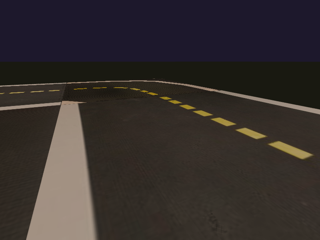

INFO:gym-duckietown:Starting at [0.51524112 0.         1.1557128 ] 1.00829092623734


In [5]:
import gym
import gym_duckietown
from IPython.display import display, clear_output
from PIL import Image

# Create the environment
env = gym.make('Duckietown-small_loop-v0')
env.reset()

# Helper function to display an image in Jupyter notebook
def show_array(arr):
    img = Image.fromarray(arr, 'RGB')
    # Make the image smaller to increase the FPS of the notebook
    img = img.resize((320, 240))
    display(img)

# Run the simulation until we're done
done = False
while not done:
    action = [0.1,0.3]
    observation, reward, done, info = env.step(action)
    frame = env.render(mode='rgb_array')

    # Clear the previous output and display the new frame
    clear_output(wait=True)
    show_array(frame)
    
    if done:
        env.reset()

env.close()

## Reload the small loop track and complete the following:

- Drive Straight
- Turn Left
- Turn Right

_Hint: Investigate the action space and try different values to the action (you can print the random action to understand the format)_

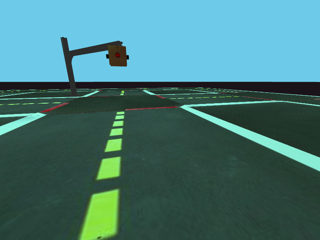

INFO:gym-duckietown:Starting at [2.65074239 0.         2.44085565] 4.728474778205286


In [3]:
import gym
import gym_duckietown
from IPython.display import display, clear_output
from PIL import Image

# Create the environment
env = gym.make('Duckietown-small_loop-v0')
env.reset()

# Helper function to display an image in Jupyter notebook
def show_array(arr):
    img = Image.fromarray(arr, 'RGB')
    # Make the image smaller to increase the FPS of the notebook
    img = img.resize((320, 240))
    display(img)

# Run the simulation until we're done
done = False
while not done:
    action = env.action_space.sample()
    observation, reward, done, info = env.step(action)
    frame = env.render(mode='rgb_array')

    # Clear the previous output and display the new frame
    clear_output(wait=True)
    show_array(frame)
    
    if done:
        env.reset()

env.close()

## What does the Duckiebot see?

- Inspect the observation returned by the step function, what information does it contain?

In [5]:
# Your code here

<module 'gym' from '/home/uni/dt-sim39/lib/python3.9/site-packages/gym/__init__.py'>

## Retrieving Additional Information from the Environment

You are also able to retrieve other telemtry information from the environment for each frame (timestep)
To see what other properties and methods are available run the following command:

In [5]:
dir(env.env)

['__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_action_space',
 '_is_protocol',
 '_metadata',
 '_np_random',
 '_observation_space',
 '_reward_range',
 'action_space',
 'checked_render',
 'checked_reset',
 'checked_step',
 'class_name',
 'close',
 'env',
 'metadata',
 'np_random',
 'observation_space',
 'render',
 'render_mode',
 'reset',
 'reward_range',
 'spec',
 'step',
 'unwrapped']

### The following properties may be useful:

- cur_angle (this angle is in radians)
- cur_pos 
- robot_speed, speed (try figure out the difference between these two)
- wheelVels

### The following methods may be useful:

- get_lane_pos2 (takes pos and angle as inputs)
- closest_curve_point

In [6]:
#Try out these properties the first one is there for you
postion = env.env.cur_pos


### To start from the same position every time use the following parameters after creating the environment:

In [8]:
env.env.user_tile_start = (0,0) # set this to an appropriate tile coordinate
env.env.start_pose = ([0.2,0,0.2],0) # set this to an appropriate pose ([x,y,z],theta) in the tile

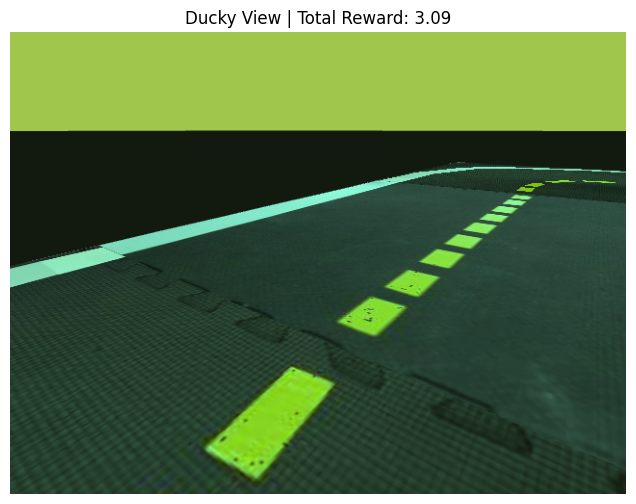

Command (w/a/s/d/q or combinations):  q


Quitting...
Controller closed.


In [3]:
import gym
import gym_duckietown
import numpy as np
from PIL import Image
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

def drive_ducky():
    """Simple driving function for Duckietown"""
    
    # Create environment
    env = gym.make('Duckietown-small_loop-v0')
    obs = env.reset()
    total_reward = 0
    
    print("DUCKY CONTROLLER STARTED!")
    print("="*40)
    print("Commands:")
    print("  w = Forward")
    print("  s = Backward")
    print("  a = Turn Left")
    print("  d = Turn Right")
    print("  q = Quit")
    print("\nCOMBINATIONS:")
    print("  wd = Forward + Right")
    print("  wa = Forward + Left")
    print("  sd = Backward + Right")
    print("  sa = Backward + Left")
    print("="*40)
    print("Type a command and press Enter:\n")
    
    # Main loop
    while True:
        # Display current view
        clear_output(wait=True)
        
        # Show the image
        plt.figure(figsize=(8, 6))
        plt.imshow(obs)
        plt.title(f'Ducky View | Total Reward: {total_reward:.2f}')
        plt.axis('off')
        plt.show()
        
        # Get command
        command = input("Command (w/a/s/d/q or combinations): ").strip().lower()
        
        # Initialize action
        action = np.array([0.0, 0.0])
        movement_description = []
        
        # Process each character in the command to combine actions
        if 'q' in command:
            print("Quitting...")
            break
        
        # Check for forward/backward
        if 'w' in command:
            action += np.array([0.5, 0.5])  # Forward
            movement_description.append("Forward")
        if 's' in command:
            action -= np.array([0.5, 0.5])  # Backward
            movement_description.append("Backward")
        
        # Check for turning
        if 'a' in command:
            action += np.array([-0.2, 0.2])  # Turn left (reduce left wheel, increase right)
            movement_description.append("Left")
        if 'd' in command:
            action += np.array([0.2, -0.2])  # Turn right (increase left wheel, reduce right)
            movement_description.append("Right")
        
        # If no valid command, stop
        if not any(c in command for c in 'wasd'):
            action = [0, 0]
            print(f"Unknown command: {command}. Stopping.")
        else:
            # Print the combined movement
            if movement_description:
                print(f"Moving: {' + '.join(movement_description)}")
        
        # Take the action
        obs, reward, done, info = env.step(action)
        total_reward += reward
        
        # Reset if episode is done
        if done:
            print(f"\n*** Episode finished! Total reward: {total_reward:.2f} ***")
            print("Resetting environment...\n")
            obs = env.reset()
            total_reward = 0
    
    env.close()
    print("Controller closed.")

# Run the controller
drive_ducky()

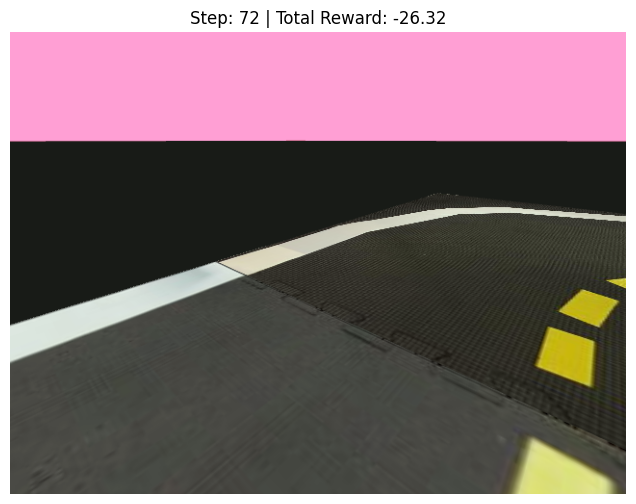

Command (w/a/s/d/q or combinations):  q


Quitting...

Recording Complete!
📁 Data saved in: ducky_session_20251104_171127/
📊 Total steps recorded: 72
🖼️ Images saved: 72
📄 Data file: ducky_session_20251104_171127/session_data.json


In [12]:
import gym
import gym_duckietown
import numpy as np
from PIL import Image
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import os
from datetime import datetime
import json

def drive_ducky_with_recording():
    """Drive Duckietown while recording data"""
    
    # Create environment
    env = gym.make('Duckietown-small_loop-v0')
    obs = env.reset()
    total_reward = 0
    
    # Create folder for this session
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    session_folder = f"ducky_session_{timestamp}"
    os.makedirs(session_folder, exist_ok=True)
    
    # Data storage
    step_counter = 0
    session_data = []
    
    print("DUCKY CONTROLLER WITH RECORDING STARTED!")
    print("="*40)
    print(f"Recording to folder: {session_folder}")
    print("="*40)
    print("Commands:")
    print("  w = Forward")
    print("  s = Backward")
    print("  a = Turn Left")
    print("  d = Turn Right")
    print("  q = Quit")
    print("\nCOMBINATIONS:")
    print("  wd = Forward + Right")
    print("  wa = Forward + Left")
    print("  sd = Backward + Right")
    print("  sa = Backward + Left")
    print("="*40)
    print("Type a command and press Enter:\n")
    
    # Main loop
    while True:
        # Display current view
        clear_output(wait=True)
        
        # Show the image
        plt.figure(figsize=(8, 6))
        plt.imshow(obs)
        plt.title(f'Step: {step_counter} | Total Reward: {total_reward:.2f}')
        plt.axis('off')
        plt.show()
        
        # Get command
        command = input("Command (w/a/s/d/q or combinations): ").strip().lower()
        
        # Initialize action
        action = np.array([0.0, 0.0])
        movement_description = []
        
        # Process each character in the command to combine actions
        if 'q' in command:
            print("Quitting...")
            break
        
        # Check for forward/backward
        if 'w' in command:
            action += np.array([0.5, 0])  # Forward
            movement_description.append("Forward")
        if 's' in command:
            action -= np.array([0.5, 0])  # Backward
            movement_description.append("Backward")
        
        # Check for turning
        if 'a' in command:
            action += np.array([0, 0.2])  # Turn left
            movement_description.append("Left")
        if 'd' in command:
            action += np.array([0, -0.2])  # Turn right
            movement_description.append("Right")
        
        # If no valid command, stop
        if not any(c in command for c in 'wasd'):
            action = np.array([0, 0])
            print(f"Unknown command: {command}. Stopping.")
        else:
            # Print the combined movement
            if movement_description:
                print(f"Moving: {' + '.join(movement_description)}")
        
        # Convert numpy array to list for JSON serialization
        action_list = action.tolist() if isinstance(action, np.ndarray) else action
        
        # Take the action
        new_obs, reward, done, info = env.step(action)
        
        # Get speed from environment if available
        speed = env.speed if hasattr(env, 'speed') else 0.0
        robot_speed = env.robot_speed if hasattr(env, 'robot_speed') else 0.0
        
        # === RECORD DATA ===
        # 1. Save image as 80x80 for training
        img_filename = f"{session_folder}/img_{step_counter:05d}.png"
        
        # Resize and save image (80x80 only)
        img = Image.fromarray(obs)
        img_resized = img.resize((80, 80), Image.LANCZOS)
        img_resized.save(img_filename)
        
        # 2. Record step data with speed and reward
        step_data = {
            'step': step_counter,
            'image': img_filename,
            'action': action_list,
            'reward': float(reward),  # Current step reward
            'speed': float(speed),  # Current speed
            'robot_speed': float(robot_speed),  # Robot speed value
            'done': done,
            'command': command,
            'total_reward': float(total_reward),  # Cumulative reward
            'step_reward': float(reward)  # Making it explicit - this step's reward
        }
        session_data.append(step_data)
        
        # Print recording info
        print(f"📸 Recorded: Step {step_counter} | Action: {action_list} | Reward: {reward:.3f} | Speed: {speed:.3f}")
        
        # Update for next step
        obs = new_obs
        total_reward += reward
        step_counter += 1
        
        # Reset if episode is done
        if done:
            print(f"\n*** Episode finished! Total reward: {total_reward:.2f} ***")
            print("Resetting environment...\n")
            obs = env.reset()
            total_reward = 0
    
    # Save session data to JSON
    json_filename = f"{session_folder}/session_data.json"
    with open(json_filename, 'w') as f:
        json.dump(session_data, f, indent=2)
    
    # Save summary
    summary_filename = f"{session_folder}/summary.txt"
    with open(summary_filename, 'w') as f:
        f.write(f"Session Summary\n")
        f.write(f"="*40 + "\n")
        f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Total steps: {step_counter}\n")
        f.write(f"Total episodes: {sum(1 for s in session_data if s['done'])}\n")
        f.write(f"Final reward: {total_reward:.3f}\n")
        f.write(f"Average reward: {np.mean([s['reward'] for s in session_data]):.3f}\n")
        if session_data and 'speed' in session_data[0]:
            speeds = [s.get('speed', 0) for s in session_data]
            f.write(f"Average speed: {np.mean(speeds):.3f}\n")
            f.write(f"Max speed: {np.max(speeds):.3f}\n")
    
    env.close()
    
    print("\n" + "="*40)
    print("Recording Complete!")
    print(f"📁 Data saved in: {session_folder}/")
    print(f"📊 Total steps recorded: {step_counter}")
    print(f"🖼️ Images saved: {step_counter}")
    print(f"📄 Data file: {json_filename}")
    print("="*40)

def load_and_view_recording(session_folder):
    """Load and visualize recorded data"""
    
    # Load JSON data
    json_filename = f"{session_folder}/session_data.json"
    with open(json_filename, 'r') as f:
        session_data = json.load(f)
    
    print(f"Loaded {len(session_data)} steps from {session_folder}")
    
    # Display sample
    for i in range(min(3, len(session_data))):
        step = session_data[i]
        
        # Load and show image
        img = Image.open(step['image'])
        
        plt.figure(figsize=(10, 4))
        
        # Image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Step {step['step']}")
        plt.axis('off')
        
        # Info
        plt.subplot(1, 2, 2)
        plt.axis('off')
        info_text = f"Step: {step['step']}\n"
        info_text += f"Command: {step['command']}\n"
        info_text += f"Action: {step['action']}\n"
        info_text += f"Reward: {step['reward']:.3f}\n"
        if 'speed' in step:
            info_text += f"Speed: {step['speed']:.3f}\n"
        if 'robot_speed' in step:
            info_text += f"Robot Speed: {step['robot_speed']:.3f}\n"
        info_text += f"Total Reward: {step['total_reward']:.3f}\n"
        info_text += f"Done: {step['done']}"
        
        plt.text(0.1, 0.5, info_text, fontsize=12, 
                verticalalignment='center', fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()
    
    return session_data

def create_training_dataset(session_folder):
    """Convert recorded data to training arrays"""
    
    # Load JSON data
    json_filename = f"{session_folder}/session_data.json"
    with open(json_filename, 'r') as f:
        session_data = json.load(f)
    
    # Create arrays
    images = []
    actions = []
    rewards = []
    speeds = []
    
    for step in session_data:
        # Load image (already 80x80)
        img = np.array(Image.open(step['image']))
        images.append(img)
        actions.append(step['action'])
        rewards.append(step['reward'])
        speeds.append(step.get('speed', 0.0))  # Get speed if available
    
    # Convert to numpy arrays
    X_images = np.array(images)
    y_actions = np.array(actions)
    y_rewards = np.array(rewards)
    y_speeds = np.array(speeds)
    
    print(f"Training Dataset Created:")
    print(f"  Images shape: {X_images.shape}")  # Should be (n, 80, 80, 3)
    print(f"  Actions shape: {y_actions.shape}")
    print(f"  Rewards shape: {y_rewards.shape}")
    print(f"  Speeds shape: {y_speeds.shape}")
    
    # Save as numpy files
    np.save(f"{session_folder}/images.npy", X_images)
    np.save(f"{session_folder}/actions.npy", y_actions)
    np.save(f"{session_folder}/rewards.npy", y_rewards)
    np.save(f"{session_folder}/speeds.npy", y_speeds)
    
    print(f"  Saved as .npy files in {session_folder}/")
    
    return X_images, y_actions, y_rewards, y_speeds

# === MAIN EXECUTION ===
print("Choose option:")
print("1. Drive and record new session")
print("2. Load previous recording (if exists)")
print("-"*40)

# Run the recording controller
drive_ducky_with_recording()

INFO:gym-duckietown:Information about the graphics card:
 pyglet_version: 1.5.27
    information: dict[4]
                 │ vendor: Mesa
                 │ renderer: llvmpipe (LLVM 20.1.2, 256 bits)
                 │ version: 4.5 (Compatibility Profile) Mesa 25.0.7-0ubuntu0.24.04.2
                 │ shading-language-version: 4.50
  nvidia_around: False
DEBUG:gym-duckietown:loading map file "/home/ballolinux/dt-sim/lib/python3.9/site-packages/duckietown_world/data/gd1/maps/small_loop.yaml"
INFO:gym-duckietown:done
INFO:gym-duckietown:Starting at [0.88418159 0.         0.34168882] 5.819098353146519
INFO:gym-duckietown:using DuckietownEnv


Using device: cuda


INFO:gym-duckietown:Starting at [1.07471436 0.         1.65311952] 5.621784324782389
DEBUG:gym-duckietown:No tile found at [1.08901342 0.         1.75878844] (1, 3)
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.0
DEBUG:gym-duckietown:pos: [1.1336799  0.         1.69853975]


Starting training for 100 episodes...


DEBUG:gym-duckietown:l_pos: [1.17834638 0.         1.63829105]
DEBUG:gym-duckietown:r_pos: [1.08901342 0.         1.75878844]
DEBUG:gym-duckietown:f_pos: [1.20597834 0.         1.75213952]


...

Episode 97 finished: Steps=39, Reward=-1969.730


DEBUG:gym-duckietown:No tile found at [-0.00809266  0.          0.91492804] (-1, 1)
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.0
DEBUG:gym-duckietown:pos: [0.06195167 0.         0.8584144 ]
DEBUG:gym-duckietown:l_pos: [0.10904637 0.         0.91678468]
DEBUG:gym-duckietown:r_pos: [0.01485698 0.         0.80004413]
DEBUG:gym-duckietown:f_pos: [-0.00809266  0.          0.91492804]
DEBUG:gym-duckietown:[1.05373735 0.         0.59440653] corresponds to tile at (1, 1) which is not drivable: {'coords': (1, 1), 'kind': 'asphalt', 'angle': 1, 'drivable': False, 'texture': <gym_duckietown.graphics.Texture object at 0x7bae5813b5e0>, 'color': array([0.83071618, 1.18005102, 0.82856955, 1.        ])}
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.3
DEBUG:gym-duckietown:pos: [1.14991837 0.         0.57842338]
DEBUG:gym-duckietown:l_pos: [1.05373735 0.     

Episode 98 finished: Steps=77, Reward=-2038.009


DEBUG:gym-duckietown:No tile found at [-0.00208     0.          0.39744563] (-1, 0)
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.0
DEBUG:gym-duckietown:pos: [0.08501574 0.         0.37476675]
DEBUG:gym-duckietown:l_pos: [0.10391481 0.         0.44734654]
DEBUG:gym-duckietown:r_pos: [0.06611667 0.         0.30218697]
DEBUG:gym-duckietown:f_pos: [-0.00208     0.          0.39744563]


Episode 99 finished: Steps=62, Reward=-1959.868

Training complete!
Model saved to ducky_dqn_episode_99.pth
Model saved to ducky_dqn_final.pth
Final Average Reward (last 10 episodes): -2031.278



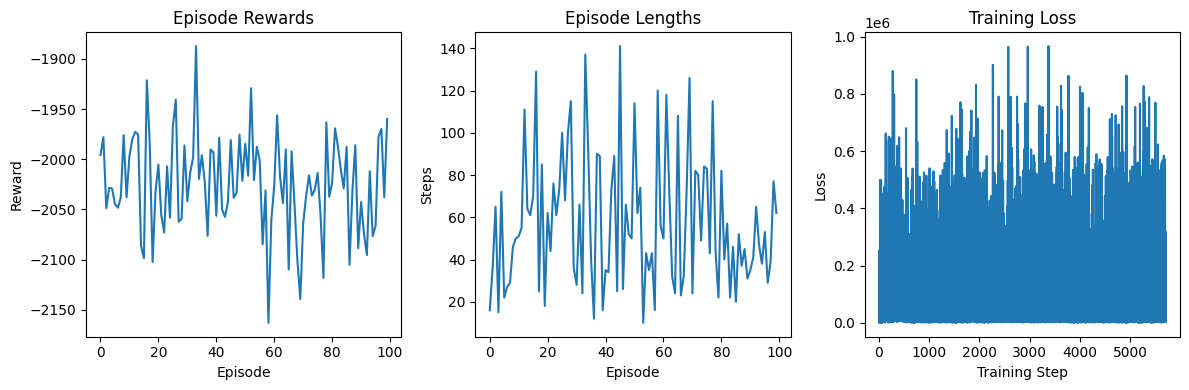

INFO:gym-duckietown:Starting at [0.79099137 0.         1.37956644] 1.037828270894772


Testing for 5 episodes...


DEBUG:gym-duckietown:[0.89319684 0.         1.16522314] corresponds to tile at (1, 1) which is not drivable: {'coords': (1, 1), 'kind': 'asphalt', 'angle': 1, 'drivable': False, 'texture': <gym_duckietown.graphics.Texture object at 0x7bae5813be50>, 'color': array([0.87987514, 1.18528989, 1.13386264, 1.        ])}
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.0
DEBUG:gym-duckietown:pos: [0.85830582 0.         1.24818468]
DEBUG:gym-duckietown:l_pos: [0.7891712  0.         1.21910882]
DEBUG:gym-duckietown:r_pos: [0.92744043 0.         1.27726053]
DEBUG:gym-duckietown:f_pos: [0.89319684 0.         1.16522314]
DEBUG:gym-duckietown:No tile found at [-0.00051273  0.          0.23366583] (-1, 0)
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.3
DEBUG:gym-duckietown:pos: [0.08948832 0.         0.19616837]
DEBUG:gym-duckietown:l_pos: [0.17948938 0.        

Test Episode 0: Reward = -1034.237


DEBUG:gym-duckietown:No tile found at [0.54811245 0.         1.76003575] (0, 3)
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.0
DEBUG:gym-duckietown:pos: [0.53602146 0.         1.67085163]
DEBUG:gym-duckietown:l_pos: [0.61034156 0.         1.6607758 ]
DEBUG:gym-duckietown:r_pos: [0.46170136 0.         1.68092746]
DEBUG:gym-duckietown:f_pos: [0.54811245 0.         1.76003575]
INFO:gym-duckietown:Starting at [1.45084239 0.         0.31617995] 5.382785324337669


...

Test Episode 2: Reward = -1044.237


DEBUG:gym-duckietown:No tile found at [1.75500488 0.         0.91068689] (3, 1)
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.0
DEBUG:gym-duckietown:pos: [1.6923755 0.        0.951949 ]
DEBUG:gym-duckietown:l_pos: [1.75500488 0.         0.91068689]
DEBUG:gym-duckietown:r_pos: [1.62974613 0.         0.99321111]
DEBUG:gym-duckietown:f_pos: [1.74189003 0.         1.02710425]
INFO:gym-duckietown:Starting at [1.27269812 0.         1.33314408] 0.449616424087031


Test Episode 3: Reward = -1038.855


DEBUG:gym-duckietown:No tile found at [1.7606667  0.         1.09809433] (3, 1)
DEBUG:gym-duckietown:Invalid pose. Collision free: True On drivable area: False
DEBUG:gym-duckietown:safety_factor: 1.0
DEBUG:gym-duckietown:pos: [1.67948159 0.         1.1369399 ]
DEBUG:gym-duckietown:l_pos: [1.64711028 0.         1.06928564]
DEBUG:gym-duckietown:r_pos: [1.71185289 0.         1.20459416]
DEBUG:gym-duckietown:f_pos: [1.7606667  0.         1.09809433]


Test Episode 4: Reward = -1021.985
Average Test Reward: -1053.373


In [7]:
import gym
import gym_duckietown
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import os
from datetime import datetime

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class FrameStack:
    """Stack the last k frames for temporal information"""
    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)
    
    def reset(self, observation):
        """Initialize with first observation"""
        # Convert to 80x80 if needed
        if observation.shape[0] != 80:
            obs_pil = Image.fromarray(observation)
            obs_pil = obs_pil.resize((80, 80), Image.LANCZOS)
            observation = np.array(obs_pil)
        
        # Normalize to [0, 1]
        observation = observation.astype(np.float32) / 255.0
        
        # Stack k copies of first frame
        for _ in range(self.k):
            self.frames.append(observation)
        
        return self.get_state()
    
    def push(self, observation):
        """Add new frame and return stacked state"""
        # Convert to 80x80 if needed
        if observation.shape[0] != 80:
            obs_pil = Image.fromarray(observation)
            obs_pil = obs_pil.resize((80, 80), Image.LANCZOS)
            observation = np.array(obs_pil)
        
        # Normalize
        observation = observation.astype(np.float32) / 255.0
        self.frames.append(observation)
        
        return self.get_state()
    
    def get_state(self):
        """Get current state as stacked frames"""
        # Stack frames along channel dimension
        # Shape: (4*3, 80, 80) = (12, 80, 80)
        stacked = np.concatenate(list(self.frames), axis=2)
        # Transpose to (C, H, W) for PyTorch
        stacked = np.transpose(stacked, (2, 0, 1))
        return stacked

class DQN(nn.Module):
    """Deep Q-Network for continuous action space"""
    def __init__(self, input_channels=12, n_actions=2):
        super(DQN, self).__init__()
        
        # CNN layers for image processing
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        
        # Calculate size after convolutions
        def conv2d_size_out(size, kernel_size, stride):
            return (size - (kernel_size - 1) - 1) // stride + 1
        
        convw = conv2d_size_out(conv2d_size_out(conv2d_size_out(80, 8, 4), 4, 2), 3, 1)
        convh = conv2d_size_out(conv2d_size_out(conv2d_size_out(80, 8, 4), 4, 2), 3, 1)
        linear_input_size = convw * convh * 64
        
        # Fully connected layers
        self.fc1 = nn.Linear(linear_input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        
        # Separate heads for each action dimension
        self.action1_head = nn.Linear(256, 11)  # Discretize [-0.5, 0.5] into 11 bins
        self.action2_head = nn.Linear(256, 11)  # Discretize [-0.2, 0.2] into 11 bins
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        # Output Q-values for discretized actions
        action1_q = self.action1_head(x)
        action2_q = self.action2_head(x)
        
        return action1_q, action2_q

class ReplayMemory:
    """Experience replay buffer"""
    def __init__(self, capacity=10000):
        self.memory = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        
        return (torch.FloatTensor(state).to(device),
                torch.LongTensor(action).to(device),
                torch.FloatTensor(reward).to(device),
                torch.FloatTensor(next_state).to(device),
                torch.FloatTensor(done).to(device))
    
    def __len__(self):
        return len(self.memory)

class DuckyRL:
    """Main RL training class"""
    def __init__(self, env_name='Duckietown-small_loop-v0', lr=1e-4):
        self.env = gym.make(env_name)
        self.frame_stack = FrameStack(k=4)
        
        # Networks
        self.q_network = DQN(input_channels=12).to(device)
        self.target_network = DQN(input_channels=12).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        
        # Training components
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.memory = ReplayMemory(capacity=10000)
        
        # Action space discretization
        self.action1_space = np.linspace(0.01, 1, 11)  # Forward/backward
        self.action2_space = np.linspace(-1, 1, 11)  # Left/right turn
        
        # Training parameters
        self.batch_size = 32
        self.gamma = 0.99
        self.eps_start = 1.0
        self.eps_end = 0.01
        self.eps_decay = 0.995
        self.epsilon = self.eps_start
        
        # Logging
        self.episode_rewards = []
        self.episode_lengths = []
        self.training_losses = []
    
    def discretize_action(self, continuous_action):
        """Convert continuous action to discrete indices"""
        idx1 = np.argmin(np.abs(self.action1_space - continuous_action[0]))
        idx2 = np.argmin(np.abs(self.action2_space - continuous_action[1]))
        return [idx1, idx2]
    
    def get_continuous_action(self, discrete_indices):
        """Convert discrete indices back to continuous actions"""
        return [self.action1_space[discrete_indices[0]], 
                self.action2_space[discrete_indices[1]]]
    
    def select_action(self, state):
        """Epsilon-greedy action selection"""
        if random.random() < self.epsilon:
            # Random action
            return [random.randint(0, 10), random.randint(0, 10)]
        else:
            # Greedy action from Q-network
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q1, q2 = self.q_network(state_tensor)
                action1 = q1.max(1)[1].item()
                action2 = q2.max(1)[1].item()
                return [action1, action2]

    def calculate_reward(self, base_reward, action, done):
        """
        Custom reward function that encourages faster driving
        
        Args:
            base_reward: Original reward from environment
            action: [velocity, steering] continuous action
            done: Whether episode ended
        
        Returns:
            modified_reward: Enhanced reward with speed bonus
        """
        velocity = action[0]  # Forward speed
        steering = abs(action[1])  # Absolute steering angle
        
        # Start with base reward
        reward = base_reward
        
        # Speed bonus: reward faster forward movement
        speed_bonus = velocity * 0.5  # Adjust multiplier as needed
        reward += speed_bonus
        
        # Penalty for sharp turns (encourages smooth driving)
        #steering_penalty = steering * 0.2
        #reward -= steering_penalty
        
        # Large penalty for crashing/going off track
        if done and base_reward < 0:
            reward -= 1000  # Crash penalty
        
        return reward
    
    def optimize_model(self):
        """Train the Q-network"""
        if len(self.memory) < self.batch_size:
            return
        
        # Sample batch
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        # Current Q values
        current_q1, current_q2 = self.q_network(states)
        current_q1 = current_q1.gather(1, actions[:, 0].unsqueeze(1))
        current_q2 = current_q2.gather(1, actions[:, 1].unsqueeze(1))
        
        # Next Q values from target network
        with torch.no_grad():
            next_q1, next_q2 = self.target_network(next_states)
            next_q1_max = next_q1.max(1)[0]
            next_q2_max = next_q2.max(1)[0]
            next_q_value = (next_q1_max + next_q2_max) / 2  # Average Q-value
            
            target_q_value = rewards + (self.gamma * next_q_value * (1 - dones))
        
        # Loss
        loss1 = F.mse_loss(current_q1.squeeze(), target_q_value)
        loss2 = F.mse_loss(current_q2.squeeze(), target_q_value)
        loss = loss1 + loss2
        
        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.training_losses.append(loss.item())
    
    def train(self, num_episodes=100, save_interval=10):
        print(f"Starting training for {num_episodes} episodes...")
    
        for episode in range(num_episodes):
            obs = self.env.reset()
            state = self.frame_stack.reset(obs)
        
            episode_reward = 0
            episode_length = 0
            max_steps = 400  # Prevent infinite episodes
        
            while episode_length < max_steps:
                # Select action
                discrete_action = self.select_action(state)
                continuous_action = self.get_continuous_action(discrete_action)
                
                # Take action
                next_obs, base_reward, done, info = self.env.step(continuous_action)
                next_state = self.frame_stack.push(next_obs)

                # Custom reword
                reward = self.calculate_reward(base_reward, continuous_action, done)
                
                # Store experience
                self.memory.push(state, discrete_action, reward, next_state, done)
                
                # Optimize
                if len(self.memory) >= self.batch_size:
                    self.optimize_model()
                
                # Update state
                state = next_state
                episode_reward += reward
                episode_length += 1
                
                # Debug print every 100 steps
                if episode_length % 100 == 0:
                    print(f"Episode {episode}, Step {episode_length}: Still running...")
                
                if done:
                    break
        
            # Log completion
            print(f"Episode {episode} finished: Steps={episode_length}, Reward={episode_reward:.3f}")
            
            # Decay epsilon
            self.epsilon = max(self.eps_end, self.epsilon * self.eps_decay)
            
            # Log episode
            self.episode_rewards.append(episode_reward)
            self.episode_lengths.append(episode_length)
            
            # Update target network every 10 episodes
            if episode % 10 == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())
            
            # Print progress
            if episode % save_interval == 0:
                avg_reward = np.mean(self.episode_rewards[-save_interval:]) if len(self.episode_rewards) >= save_interval else episode_reward
                print(f"Episode {episode}: Avg Reward = {avg_reward:.3f}, Epsilon = {self.epsilon:.3f}")
                
                # Save model
                self.save_model(f"ducky_dqn_episode_{episode}.pth")

        print("\n" + "="*50)
        print("Training complete!")
        
        # Save the final model
        final_episode = num_episodes - 1
        self.save_model(f"ducky_dqn_episode_{final_episode}.pth")
        self.save_model("ducky_dqn_final.pth")  # Also save as "final" for easy access
        
        # Print final statistics
        if len(self.episode_rewards) >= 10:
            final_avg = np.mean(self.episode_rewards[-10:])
            print(f"Final Average Reward (last 10 episodes): {final_avg:.3f}")
        
        print("="*50 + "\n")
        
        self.env.close()
        
    
    def save_model(self, filename):
        """Save model weights"""
        torch.save({
            'q_network': self.q_network.state_dict(),
            'target_network': self.target_network.state_dict(),
            'optimizer': self.optimizer.state_dict(),
            'epsilon': self.epsilon,
            'episode_rewards': self.episode_rewards
        }, filename)
        print(f"Model saved to {filename}")
    
    def load_model(self, filename):
        """Load model weights"""
        checkpoint = torch.load(filename, map_location=device)
        self.q_network.load_state_dict(checkpoint['q_network'])
        self.target_network.load_state_dict(checkpoint['target_network'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        self.epsilon = checkpoint['epsilon']
        self.episode_rewards = checkpoint['episode_rewards']
        print(f"Model loaded from {filename}")
    
    def test(self, num_episodes=5):
        """Test the trained model"""
        print(f"Testing for {num_episodes} episodes...")
        
        test_rewards = []
        
        for episode in range(num_episodes):
            obs = self.env.reset()
            state = self.frame_stack.reset(obs)
            
            episode_reward = 0
            
            while True:
                # Always use greedy action during testing
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                    q1, q2 = self.q_network(state_tensor)
                    action1 = q1.max(1)[1].item()
                    action2 = q2.max(1)[1].item()
                    discrete_action = [action1, action2]
                
                continuous_action = self.get_continuous_action(discrete_action)
                
                # Take action
                next_obs, reward, done, info = self.env.step(continuous_action)
                state = self.frame_stack.push(next_obs)
                
                episode_reward += reward
                
                # Optionally render
                frame = self.env.render(mode='rgb_array')
                
                if done:
                    break
            
            test_rewards.append(episode_reward)
            print(f"Test Episode {episode}: Reward = {episode_reward:.3f}")
        
        print(f"Average Test Reward: {np.mean(test_rewards):.3f}")
        self.env.close()

# === Training Script ===
if __name__ == "__main__":
    # Initialize RL agent
    agent = DuckyRL(env_name='Duckietown-small_loop-v0', lr=1e-4)
    
    # Train the agent
    agent.train(num_episodes=100, save_interval=10)
    
    # Plot training results
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(agent.episode_rewards)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    
    plt.subplot(1, 3, 2)
    plt.plot(agent.episode_lengths)
    plt.title('Episode Lengths')
    plt.xlabel('Episode')
    plt.ylabel('Steps')
    
    if agent.training_losses:
        plt.subplot(1, 3, 3)
        plt.plot(agent.training_losses)
        plt.title('Training Loss')
        plt.xlabel('Training Step')
        plt.ylabel('Loss')
    
    plt.tight_layout()
    plt.show()
    
    # Test the trained model
    agent.test(num_episodes=5)

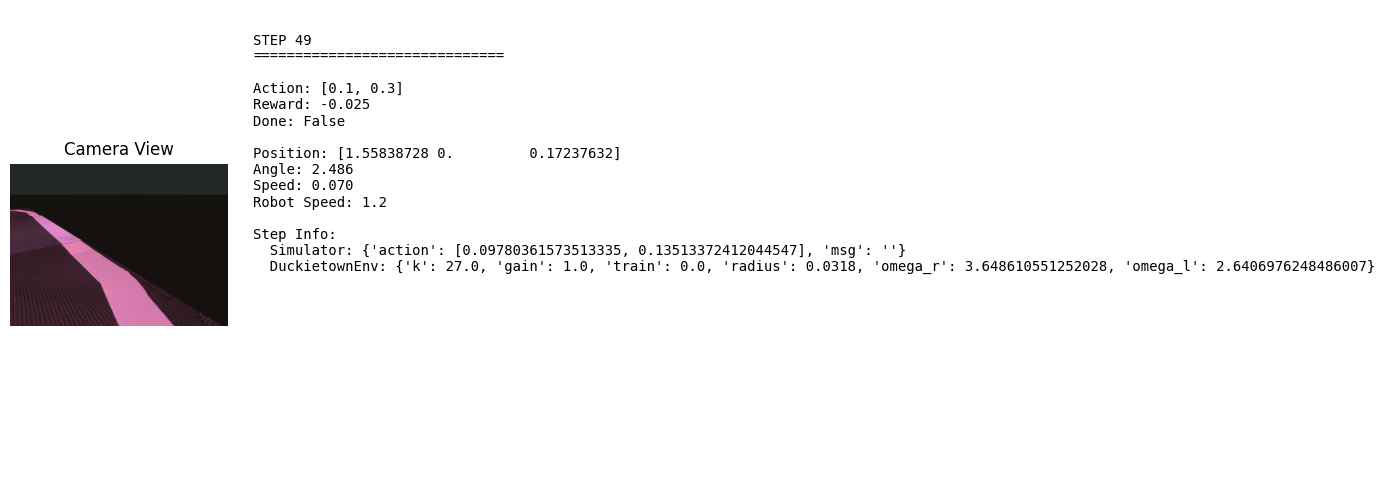

In [10]:
import gym
import gym_duckietown
from IPython.display import display, clear_output
from PIL import Image
import matplotlib.pyplot as plt

# Create the environment
env = gym.make('Duckietown-small_loop-v0')
env.reset()

# Run and show all info
done = False
step = 0

while not done and step < 50:
    # Take action
    action = [0.1, 0.3]
    observation, reward, done, info = env.step(action)
    
    # Clear screen
    clear_output(wait=True)
    
    # Show camera view and info side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Camera view
    ax1.imshow(observation)
    ax1.set_title('Camera View')
    ax1.axis('off')
    
    # All sensor info as text
    ax2.axis('off')
    
    # Collect all available info
    info_text = f"STEP {step}\n"
    info_text += "="*30 + "\n\n"
    
    # Basic info
    info_text += f"Action: [{action[0]}, {action[1]}]\n"
    info_text += f"Reward: {reward:.3f}\n"
    info_text += f"Done: {done}\n\n"
    
    # Position if available
    if hasattr(env, 'cur_pos'):
        info_text += f"Position: {env.cur_pos}\n"
    
    # Angle if available  
    if hasattr(env, 'cur_angle'):
        info_text += f"Angle: {env.cur_angle:.3f}\n"
    
    # Speed if available
    if hasattr(env, 'speed'):
        info_text += f"Speed: {env.speed:.3f}\n"
        
    # Robot speed if available
    if hasattr(env, 'robot_speed'):
        info_text += f"Robot Speed: {env.robot_speed}\n"
    
    # Lane pose if available
    if hasattr(env, 'lane_pose'):
        info_text += f"Lane Pose: {env.lane_pose}\n"
    
    # Step info dictionary
    if info:
        info_text += "\nStep Info:\n"
        for key, value in info.items():
            info_text += f"  {key}: {value}\n"
    
    # Display the text
    ax2.text(0.05, 0.95, info_text, transform=ax2.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.show()
    
    step += 1
    
    if done:
        print(f"\nEpisode done!")
        env.reset()
        done = False

env.close()

In [8]:
import gym
import gym_duckietown
from IPython.display import display, clear_output
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FrameStack:
    """Stack the last k frames"""
    def __init__(self, k=4):
        self.k = k
        self.frames = deque(maxlen=k)
    
    def reset(self, observation):
        # Resize to 80x80
        obs_pil = Image.fromarray(observation)
        obs_pil = obs_pil.resize((80, 80), Image.LANCZOS)
        observation = np.array(obs_pil).astype(np.float32) / 255.0
        
        for _ in range(self.k):
            self.frames.append(observation)
        return self.get_state()
    
    def push(self, observation):
        obs_pil = Image.fromarray(observation)
        obs_pil = obs_pil.resize((80, 80), Image.LANCZOS)
        observation = np.array(obs_pil).astype(np.float32) / 255.0
        self.frames.append(observation)
        return self.get_state()
    
    def get_state(self):
        stacked = np.concatenate(list(self.frames), axis=2)
        stacked = np.transpose(stacked, (2, 0, 1))
        return stacked

class DQN(nn.Module):
    """Network architecture - must match training"""
    def __init__(self):
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(12, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        
        # The saved model has 2304 input features to fc1
        # This corresponds to 6*6*64 = 2304
        self.fc1 = nn.Linear(2304, 512)  # Changed from 7*7*64
        self.fc2 = nn.Linear(512, 256)
        self.action1_head = nn.Linear(256, 11)
        self.action2_head = nn.Linear(256, 11)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.action1_head(x), self.action2_head(x)

# Load the model
model = DQN().to(device)
# Fix for PyTorch 2.6+ - need weights_only=False for older checkpoints
checkpoint = torch.load('ducky_dqn_final.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['q_network'])
model.eval()

# Action spaces
action1_space = np.linspace(0.01, 1, 11)
action2_space = np.linspace(-1, 1, 11)

# Create environment and frame stack
env = gym.make('Duckietown-small_loop-v0')
frame_stack = FrameStack(k=4)

# Helper function to display
def show_array(arr):
    img = Image.fromarray(arr, 'RGB')
    img = img.resize((320, 240))
    display(img)

# Reset and initialize
obs = env.reset()
state = frame_stack.reset(obs)
done = False
step_count = 0
total_reward = 0

print("Running trained model (no random actions)...")
print("-" * 40)

# Run the simulation
while not done:
    # Get action from trained model
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        q1, q2 = model(state_tensor)
        
        # Get best actions (greedy, no exploration)
        action1_idx = q1.argmax().item()
        action2_idx = q2.argmax().item()
        
        # Convert to continuous actions
        action = [action1_space[action1_idx], action2_space[action2_idx]]
    
    # Step the environment
    observation, reward, done, info = env.step(action)
    state = frame_stack.push(observation)
    
    # Track progress
    total_reward += reward
    step_count += 1
    
    # Render and display
    frame = env.render(mode='rgb_array')
    clear_output(wait=True)
    show_array(frame)
    
    # Show current stats
    print(f"Step: {step_count} | Action: [{action[0]:.2f}, {action[1]:.2f}] | Reward: {reward:.3f} | Total: {total_reward:.3f}")
    
    # Reset if done
    if done:
        print(f"\nEpisode finished! Total steps: {step_count}, Total reward: {total_reward:.3f}")
        obs = env.reset()
        state = frame_stack.reset(obs)
        done = False
        step_count = 0
        total_reward = 0

env.close()

KeyboardInterrupt: 

In [1]:
!pip freeze > requirements.txt